## Импорты библиотек

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import KFold, learning_curve
from sklearn.ensemble import RandomForestRegressor
from catboost import CatBoostRegressor
from lightgbm import LGBMRegressor
from xgboost import XGBRegressor
import shap
import warnings
warnings.filterwarnings('ignore')

## Загрузка данных

In [4]:
train = pd.read_csv('../data/processed/train_with_engineered_features.csv')
test  = pd.read_csv('../data/processed/test_with_engineered_features.csv')

"\ntrain = pd.read_csv('../data/processed/train_with_engineered_features.csv')\ntest  = pd.read_csv('../data/processed/test_with_engineered_features.csv')\n"

In [5]:
train.head()

,"IC50, mM","CC50, mM",SI,MaxAbsEStateIndex,MaxEStateIndex,MinAbsEStateIndex,MinEStateIndex,qed,SPS,MolWt,...,fr_unbrch_alkane,fr_urea,Feature_Density_Wt,Feature_LogP_Surface,Feature_Arom_Ratio,Feature_Valence_per_Atom,Feature_Complexity,"sqrt_IC50, mM","sqrt_CC50, mM",sqrt_SI
0,102.414420,95.757483,0.935000,5.466584,5.466584,0.719259,0.719259,0.681165,18.307692,195.287,...,0,0,15.022065,0.026199,0.499998,5.384611,504.292077,10.120001,9.785575,0.966954
1,0.044333,8.401080,189.500000,11.492712,11.492712,0.012350,-3.798024,0.769122,27.652174,360.907,...,0,0,15.691602,0.020841,0.499998,5.652171,1489.722453,0.210554,2.898462,13.765900
2,4.437964,50.085589,11.285714,5.366084,5.366084,0.522930,0.522930,0.612606,24.608696,315.457,...,0,0,13.715516,0.027420,0.249999,5.478258,875.271184,2.106647,7.077117,3.359422
3,6.827881,682.788051,100.000000,13.317130,13.317130,0.020658,-4.829339,0.345823,12.400000,439.375,...,0,0,14.645828,0.028896,0.999997,5.199998,2468.386395,2.613021,26.130213,10.000000
4,2.003253,70.001455,34.943894,6.320833,6.320833,0.300347,0.300347,0.562066,60.272727,151.253,...,0,0,13.750260,0.028003,0.000000,5.636359,291.054049,1.415363,8.366687,5.911336


In [6]:
SEED = 42
N_SPLITS = 5
TARGETS = ['sqrt_IC50, mM', 'sqrt_CC50, mM', 'sqrt_SI']
TARGETS_ORIG = ['IC50, mM', 'CC50, mM', 'SI']

def custom_rmse(y_true_ic, y_true_cc, y_true_si, y_pred_ic, y_pred_cc, y_pred_si):
    rmse_ic = np.sqrt(np.mean((y_true_ic - y_pred_ic)**2))
    rmse_cc = np.sqrt(np.mean((y_true_cc - y_pred_cc)**2))
    rmse_si = np.sqrt(np.mean((y_true_si - y_pred_si)**2))
    return (rmse_ic + rmse_cc + rmse_si) / 3.0

In [7]:
exclude = TARGETS + TARGETS_ORIG + ['index']
feature_cols = [c for c in train.columns if c not in exclude]

X = train[feature_cols].values
y = train[TARGETS].values
y_orig = train[TARGETS_ORIG].values
X_test = test[feature_cols].values

print(f"Train: {X.shape}, Test: {X_test.shape}")
print(f"Таргеты (sqrt): {TARGETS}")

Train: (729, 197), Test: (250, 197)
Таргеты (sqrt): ['sqrt_IC50, mM', 'sqrt_CC50, mM', 'sqrt_SI']


## Параметры моделей

In [8]:
models_config = {
    'RandomForest': (RandomForestRegressor, {
        'n_estimators': 300, 'max_depth': 10, 'n_jobs': -1
    }),
    'CatBoost': (CatBoostRegressor, {
        'iterations': 500, 'depth': 6, 'learning_rate': 0.05, 'verbose': 0
    }),
    'LightGBM': (LGBMRegressor, {
        'n_estimators': 500, 'max_depth': 6, 'learning_rate': 0.05, 'verbose': -1
    }),
    'XGBoost': (XGBRegressor, {
        'n_estimators': 500, 'max_depth': 6, 'learning_rate': 0.05, 'verbosity': 0
    }),
}

## Предсказание

In [9]:

def train_cv_formula(X, y, X_test, model_class, params):
    """
    Прямое предсказание только двух таргетов (IC50, CC50).
    SI вычисляется по формуле.
    Кросс-валидация 5 фолдов.
    """
    kf = KFold(n_splits=N_SPLITS, shuffle=True, random_state=SEED)
    preds_oof = np.zeros_like(y)
    preds_test = np.zeros((len(X_test), 3))

    for train_idx, val_idx in kf.split(X):
        fold_val = np.zeros((len(val_idx), 3))
        fold_test = np.zeros((len(X_test), 3))

        for target_idx in [0, 1]:
            model = model_class(**params, random_state=SEED)
            model.fit(X[train_idx], y[train_idx, target_idx])
            fold_val[:, target_idx] = model.predict(X[val_idx])
            fold_test[:, target_idx] = model.predict(X_test)

        fold_val[:, 2] = fold_val[:, 1] / (fold_val[:, 0] + 1e-5)
        fold_test[:, 2] = fold_test[:, 1] / (fold_test[:, 0] + 1e-5)

        preds_oof[val_idx] = fold_val
        preds_test += fold_test / N_SPLITS

    preds_oof[:, 2] = np.clip(preds_oof[:, 2], 0, 4000)
    preds_test[:, 2] = np.clip(preds_test[:, 2], 0, 4000)

    return preds_oof, preds_test


## Прогон всех моделей

In [10]:
train_cv = train_cv_formula

results = {}
for name, (model_class, params) in models_config.items():
    preds_oof, preds_test = train_cv(X, y, X_test, model_class, params)
    rmse = custom_rmse(
        y_orig[:, 0], y_orig[:, 1], y_orig[:, 2],
        np.clip(preds_oof[:, 0], 0, None)**2,
        np.clip(preds_oof[:, 1], 0, None)**2,
        np.clip(preds_oof[:, 2], 0, None)**2
    )
    results[name] = {'preds_oof': preds_oof, 'preds_test': preds_test, 'rmse': rmse}
    print(f"{name:<15} RMSE: {rmse:.4f}")

best_model = min(results, key=lambda x: results[x]['rmse'])
print(f"\nЛучшая модель: {best_model} (RMSE: {results[best_model]['rmse']:.4f})")

RandomForest    RMSE: 314.9483
CatBoost        RMSE: 310.5185
LightGBM        RMSE: 322.0200
XGBoost         RMSE: 321.3709

Лучшая модель: CatBoost (RMSE: 310.5185)


## Сравнение RMSE всех моделей (barh)

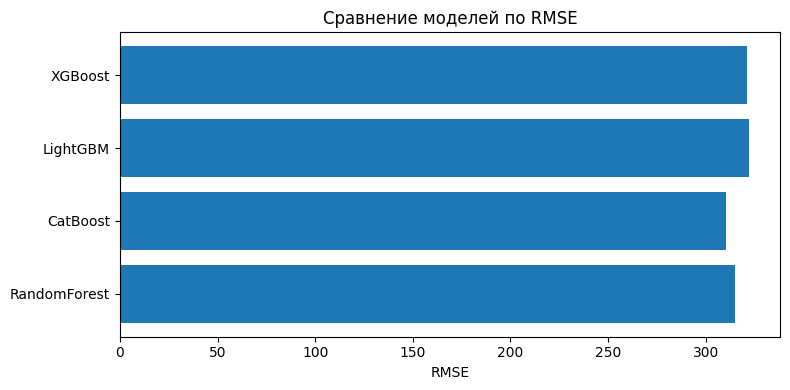

In [11]:
rmse_values = {name: results[name]['rmse'] for name in results}
plt.figure(figsize=(8, 4))
plt.barh(list(rmse_values.keys()), list(rmse_values.values()))
plt.xlabel('RMSE')
plt.title('Сравнение моделей по RMSE')
plt.tight_layout()
plt.show()

Сравнение ансамблевых моделей машинного обучения показало, что наилучшее качество прогнозирования продемонстрировала модель CatBoost с минимальным значением ошибки RMSE = 310.52. Модели Random Forest, LightGBM и XGBoost показали несколько худшие результаты.

## Важность признаков — для каждой модели, все 3 цели

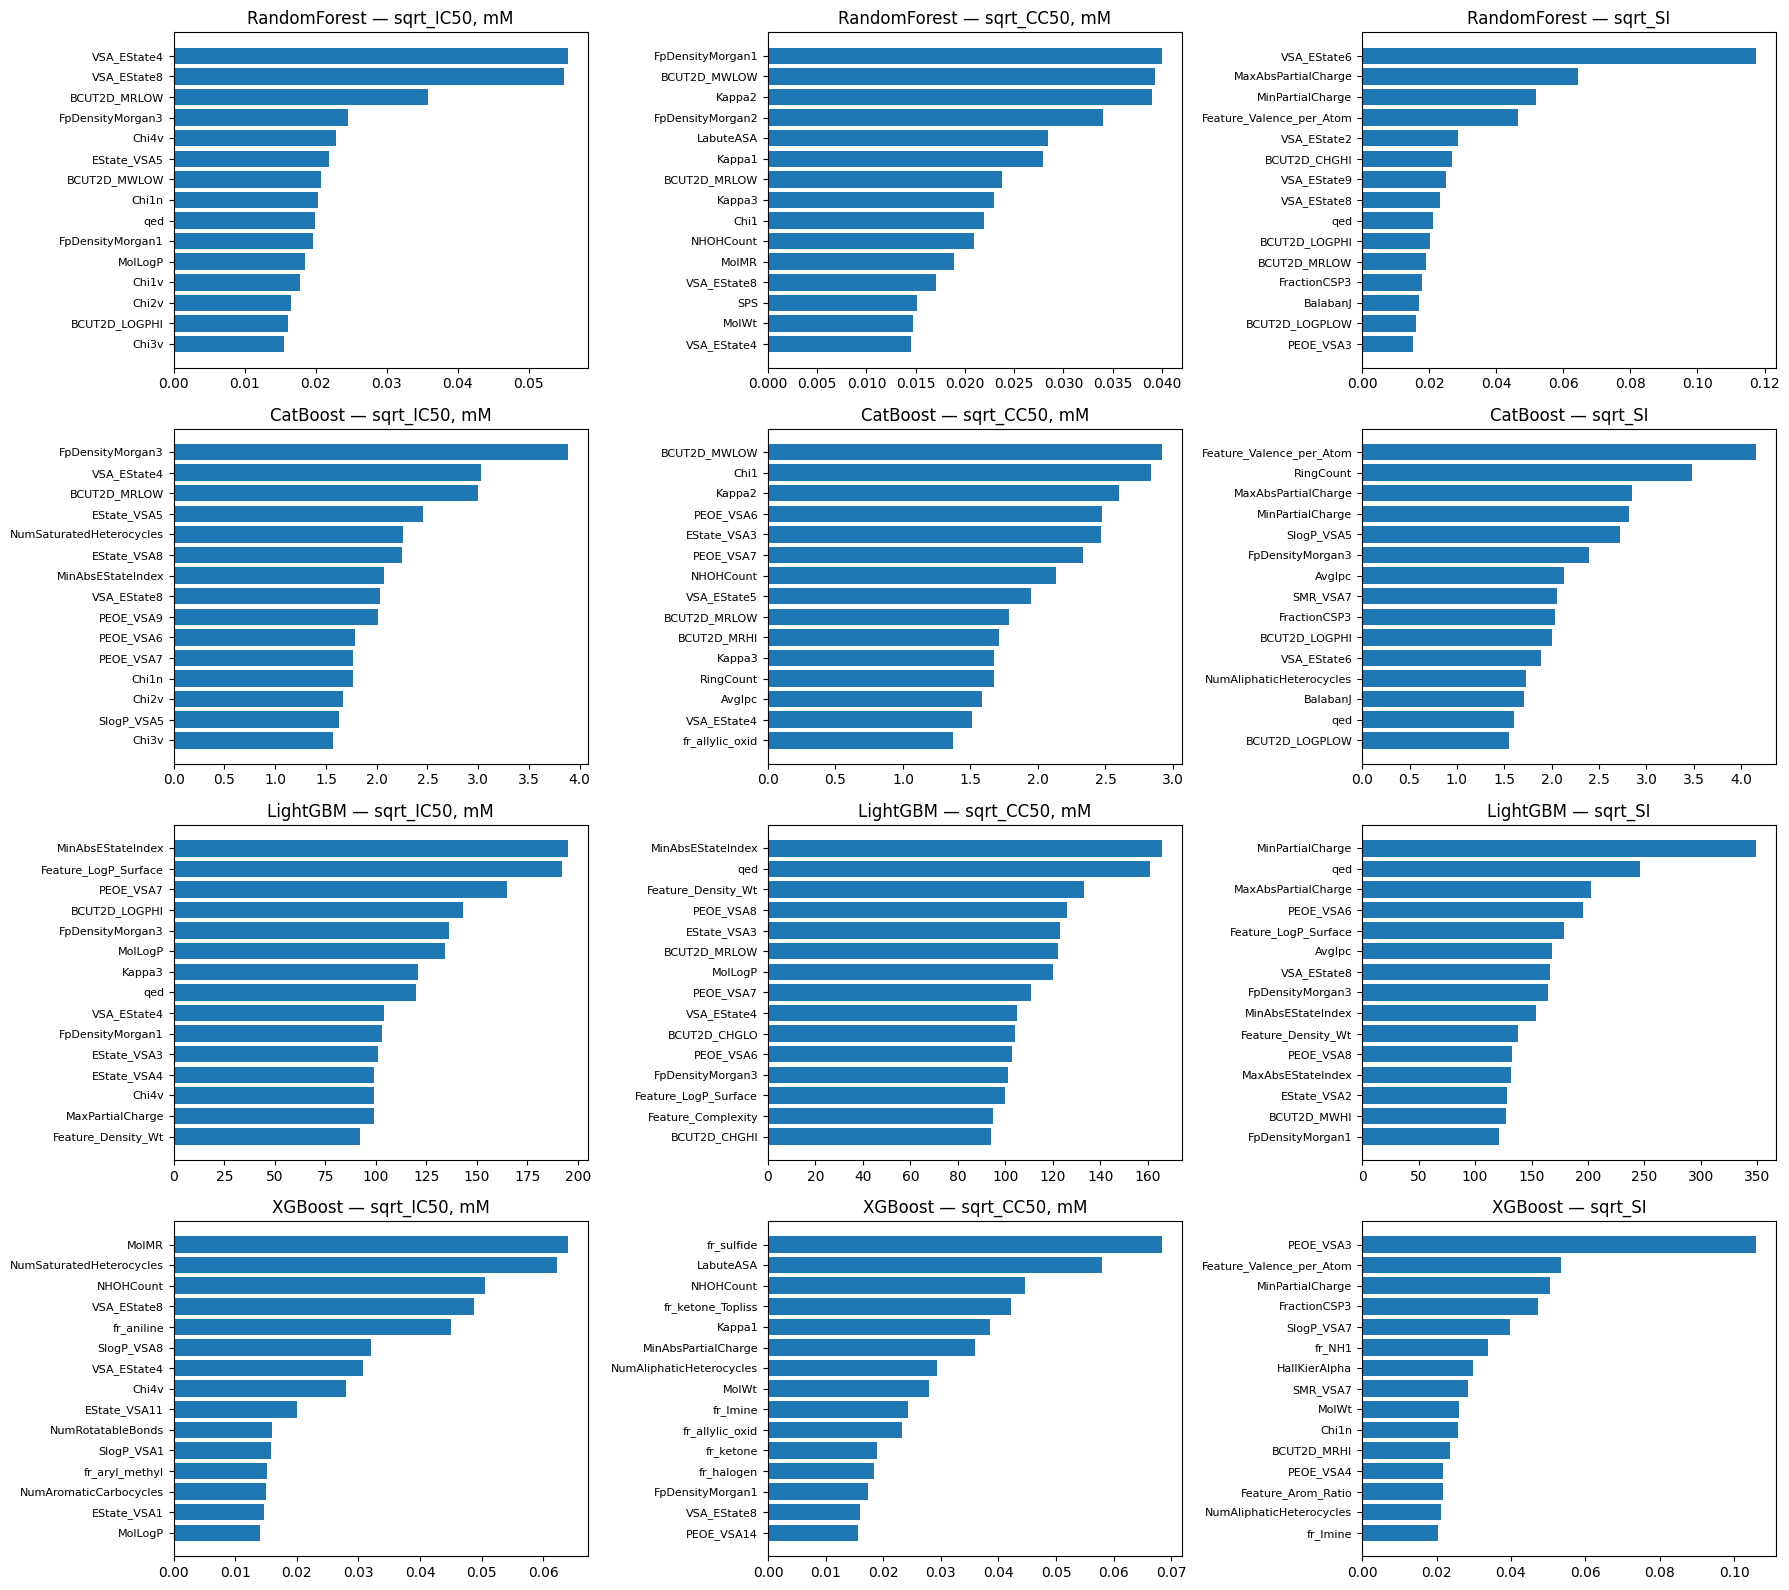

In [12]:
fig, axes = plt.subplots(len(models_config), 3, figsize=(18, 4 * len(models_config)))

for row, (name, (model_class, params)) in enumerate(models_config.items()):
    for col, target_name in enumerate(TARGETS):
        model = model_class(**params, random_state=SEED)
        model.fit(X, y[:, col])

        if hasattr(model, 'feature_importances_'):
            imp = model.feature_importances_
            top_idx = np.argsort(imp)[-15:]
            axes[row, col].barh(range(15), imp[top_idx])
            axes[row, col].set_yticks(range(15))
            axes[row, col].set_yticklabels([feature_cols[i] for i in top_idx], fontsize=8)
            axes[row, col].set_title(f'{name} — {target_name}')
        else:
            axes[row, col].text(0.5, 0.5, 'Нет importance', ha='center', va='center')

plt.tight_layout()
plt.show()

## Сравнение топ-признаков между CatBoost, LightGBM, XGBoost для каждой цели

In [13]:
boost_names = ['CatBoost', 'LightGBM', 'XGBoost']

for target_idx, target_name in enumerate(TARGETS):
    top_sets = {}
    for name in boost_names:
        model_class, params = models_config[name]
        model = model_class(**params, random_state=SEED)
        model.fit(X, y[:, target_idx])
        imp = model.feature_importances_
        top10 = set(np.array(feature_cols)[np.argsort(imp)[-10:]])
        top_sets[name] = top10

    common = top_sets[boost_names[0]] & top_sets[boost_names[1]] & top_sets[boost_names[2]]
    pairwise = {}
    for i, n1 in enumerate(boost_names):
        for n2 in boost_names[i+1:]:
            pairwise[f'{n1} & {n2}'] = len(top_sets[n1] & top_sets[n2])

    print(f"\n{target_name}:")
    print(f"  Общих для всех трёх: {len(common)} — {sorted(common)}")
    for pair, count in pairwise.items():
        print(f"  Общих {pair}: {count}/10")


sqrt_IC50, mM:
  Общих для всех трёх: 1 — [np.str_('VSA_EState4')]
  Общих CatBoost & LightGBM: 3/10
  Общих CatBoost & XGBoost: 3/10
  Общих LightGBM & XGBoost: 1/10

sqrt_CC50, mM:
  Общих для всех трёх: 0 — []
  Общих CatBoost & LightGBM: 3/10
  Общих CatBoost & XGBoost: 1/10
  Общих LightGBM & XGBoost: 0/10

sqrt_SI:
  Общих для всех трёх: 1 — [np.str_('MinPartialCharge')]
  Общих CatBoost & LightGBM: 4/10
  Общих CatBoost & XGBoost: 4/10
  Общих LightGBM & XGBoost: 1/10


Анализ важности признаков показал, что модели используют разные наборы дескрипторов для предсказания биологической активности и токсичности, что дополнительно подтверждает нелинейный характер зависимостей в данных.

Для sqrt_IC50 единственным общим признаком для всех трёх бустинговых моделей оказался VSA_EState4, что указывает на устойчивую значимость поверхностно-электронных характеристик молекулы при прогнозировании противовирусной активности.

Для sqrt_CC50 полного пересечения между моделями не наблюдается, однако наиболее часто повторяются топологические (Chi1, Kappa2) и электронно-поверхностные (PEOE_VSA3, VSA_EState5) дескрипторы. Это свидетельствует о более сложной природе факторов, влияющих на цитотоксичность.

Для sqrt_SI все модели выделяют MinPartialCharge как один из ключевых признаков, что указывает на важность распределения частичных зарядов для оценки селективности соединений. Дополнительно часто встречаются дескрипторы липофильности (SlogP_VSA5, SlogP_VSA7), топологические характеристики (FractionCSP3, HallKierAlpha) и VSA/EState-признаки.

Несмотря на различия между моделями, наиболее информативными оказались следующие группы дескрипторов:

электронные и зарядовые характеристики;
поверхностные VSA-дескрипторы;
топологические и структурные признаки;
специальные BCUT/EState/Morgan-дескрипторы.

Полученные результаты согласуются с ранее проведённым корреляционным анализом: линейные связи с таргетами были слабыми, однако ансамблевые нелинейные модели выявили значимые комбинации признаков и скрытые зависимости между структурой молекул и биологическими свойствами.

## Графики Actual vs Predicted для всех моделей

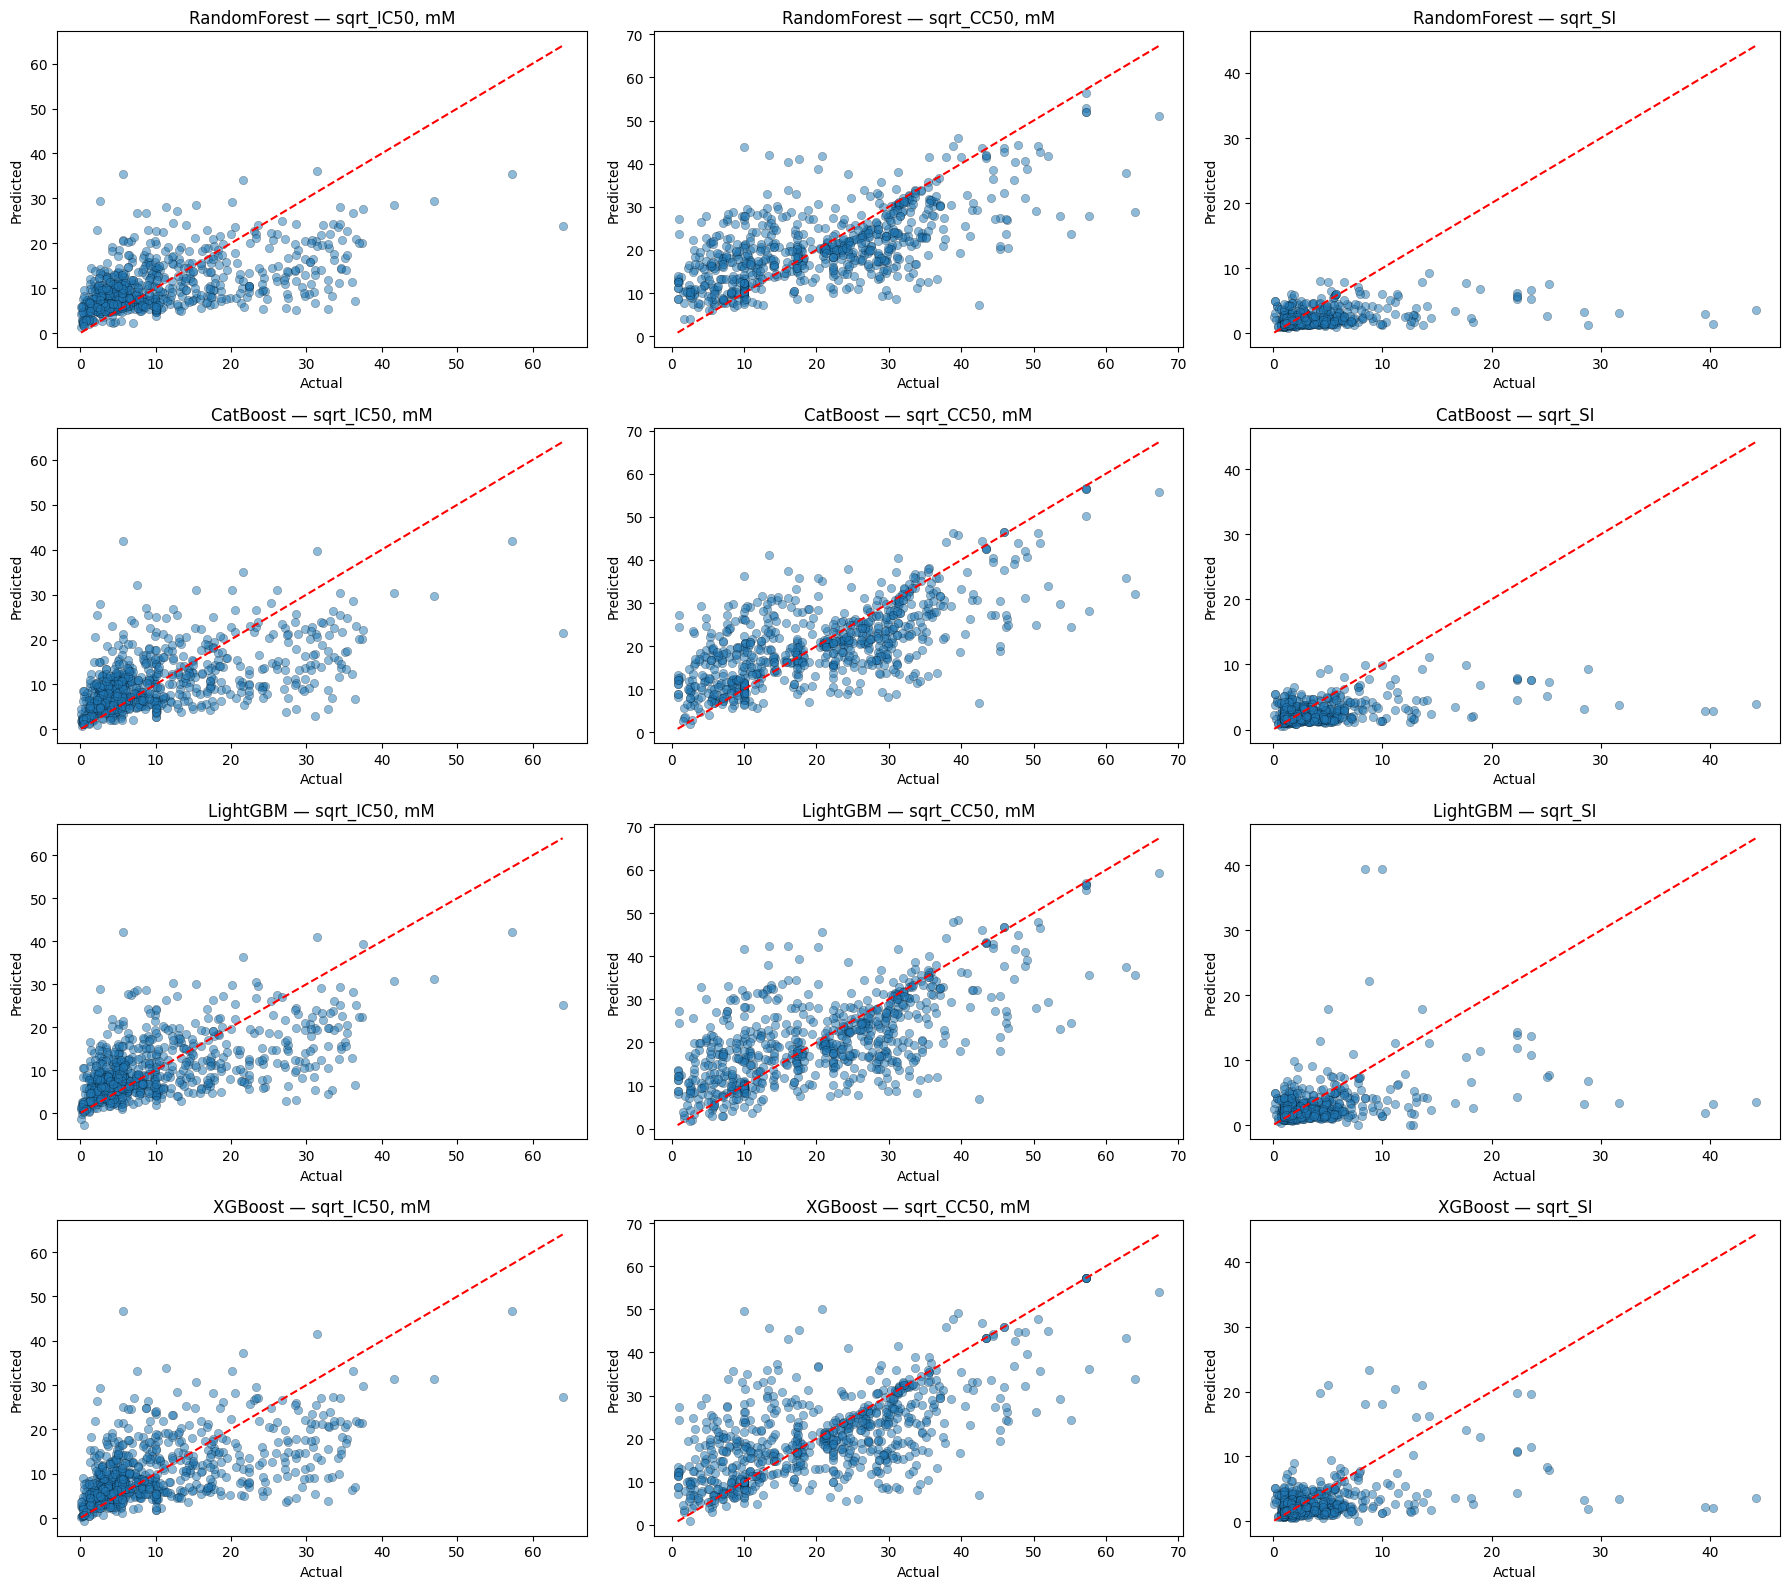

In [14]:
fig, axes = plt.subplots(len(models_config), 3, figsize=(18, 4 * len(models_config)))

for row, (name, res) in enumerate(results.items()):
    preds_oof = res['preds_oof']
    for col, target_name in enumerate(TARGETS):
        axes[row, col].scatter(y[:, col], preds_oof[:, col], alpha=0.5, edgecolors='k', linewidth=0.3)
        axes[row, col].plot([y[:, col].min(), y[:, col].max()],
                            [y[:, col].min(), y[:, col].max()], 'r--')
        axes[row, col].set_xlabel('Actual')
        axes[row, col].set_ylabel('Predicted')
        axes[row, col].set_title(f'{name} — {target_name}')

plt.tight_layout()
plt.show()

Графики предсказаний показывают, что все ансамблевые модели улавливают общий тренд зависимости между признаками и целевыми переменными, однако качество прогнозирования существенно различается для разных таргетов.

Для sqrt_CC50 наблюдается наиболее выраженная линейная зависимость между реальными и предсказанными значениями: точки располагаются ближе к диагонали, а модели лучше воспроизводят распределение данных. Наиболее стабильные результаты демонстрирует CatBoost, что согласуется с минимальным значением RMSE.

Для sqrt_IC50 модели также улавливают общую тенденцию, однако разброс точек значительно выше. При увеличении реальных значений наблюдается систематическое занижение предсказаний, что указывает на сложность прогнозирования высокоактивных соединений и наличие выраженной нелинейности в данных.

Наиболее сложным таргетом оказался sqrt_SI. Большинство предсказаний концентрируется в области малых значений, тогда как крупные значения селективного индекса воспроизводятся плохо. Это свидетельствует о высокой дисперсии таргета, наличии выбросов и ограниченной способности моделей корректно описывать экстремальные значения SI.

В целом ансамблевые модели успешно выявляют скрытые нелинейные зависимости между молекулярными дескрипторами и биологическими свойствами соединений, однако точность прогнозирования существенно зависит от природы целевой переменной.

## Residuals для всех моделей

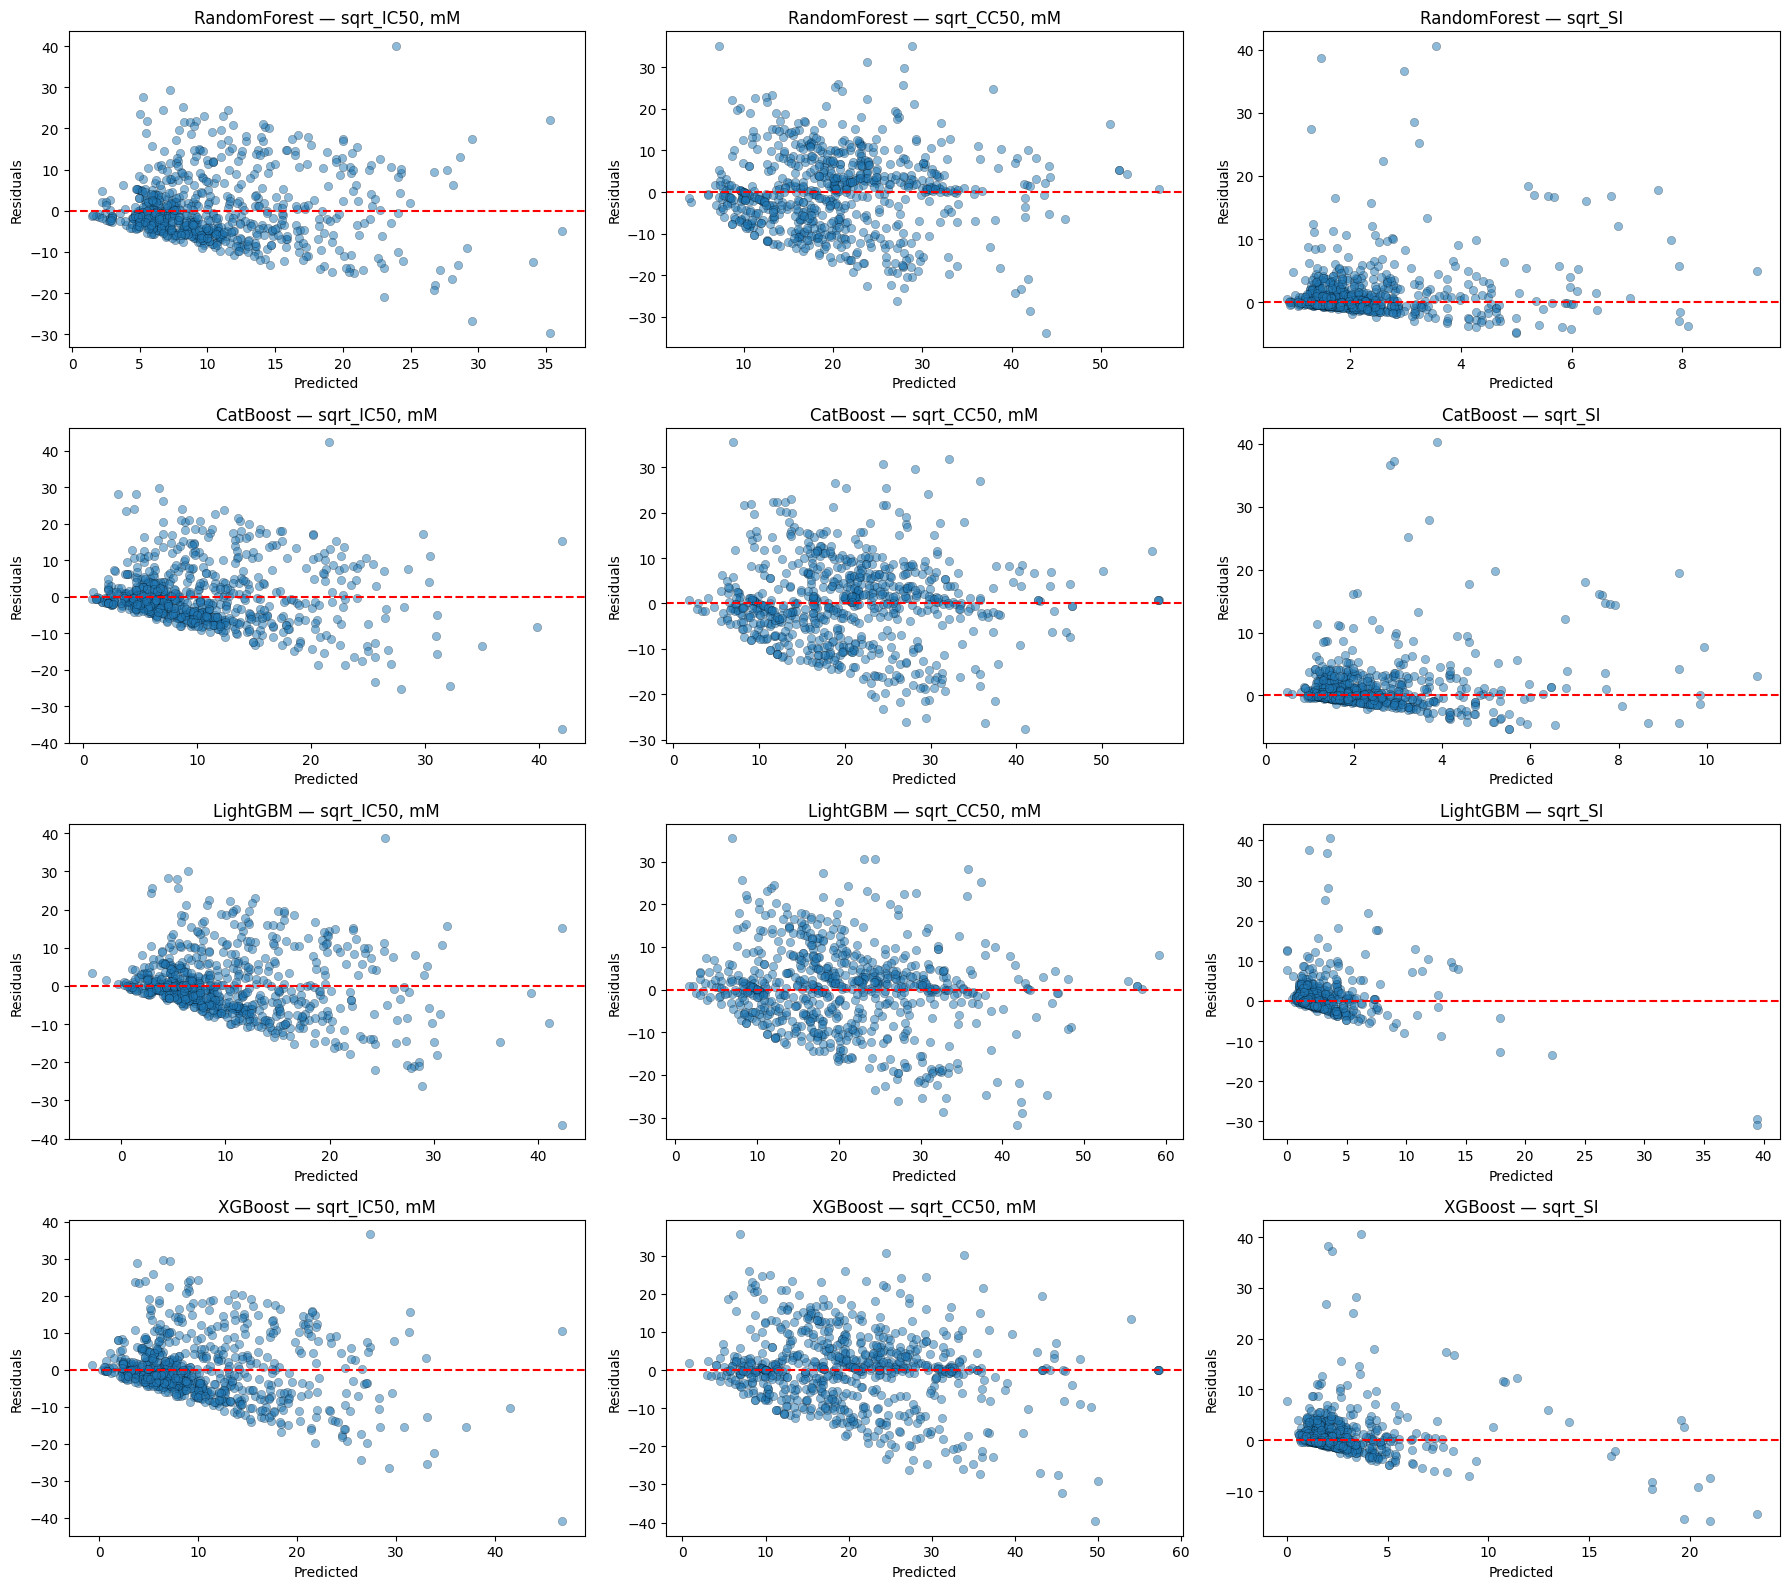

In [15]:
fig, axes = plt.subplots(len(models_config), 3, figsize=(18, 4 * len(models_config)))

for row, (name, res) in enumerate(results.items()):
    preds_oof = res['preds_oof']
    for col, target_name in enumerate(TARGETS):
        residuals = y[:, col] - preds_oof[:, col]
        axes[row, col].scatter(preds_oof[:, col], residuals, alpha=0.5, edgecolors='k', linewidth=0.3)
        axes[row, col].axhline(y=0, color='r', linestyle='--')
        axes[row, col].set_xlabel('Predicted')
        axes[row, col].set_ylabel('Residuals')
        axes[row, col].set_title(f'{name} — {target_name}')

plt.tight_layout()
plt.show()

Анализ графиков остатков показывает, что ошибки моделей распределены неслучайно, что подтверждает наличие сложных нелинейных зависимостей и гетероскедастичности в данных.

Для sqrt_IC50 у всех моделей наблюдается характерная «веерообразная» структура остатков: при увеличении предсказанных значений возрастает разброс ошибок. Одновременно заметна тенденция к отрицательным остаткам в области высоких предсказаний, что указывает на систематическое переоценивание части высокоактивных соединений.

Для sqrt_CC50 остатки распределены более симметрично относительно нуля, однако также сохраняется рост дисперсии при увеличении предсказаний. По сравнению с другими таргетами ошибки выглядят наиболее стабильными, что согласуется с лучшим качеством моделей для CC50.

Для sqrt_SI наблюдается наиболее нестабильное распределение остатков: большая часть точек сосредоточена около нуля, но присутствуют крупные положительные и отрицательные выбросы. Это свидетельствует о высокой чувствительности моделей к редким экстремальным значениям селективного индекса.

Среди моделей наиболее устойчивое распределение остатков демонстрирует CatBoost: ошибки более компактны и менее подвержены экстремальным выбросам. LightGBM и XGBoost показывают больший разброс ошибок на высоких значениях таргетов, тогда как RandomForest сильнее сглаживает предсказания.

## Кривые обучения для всех моделей

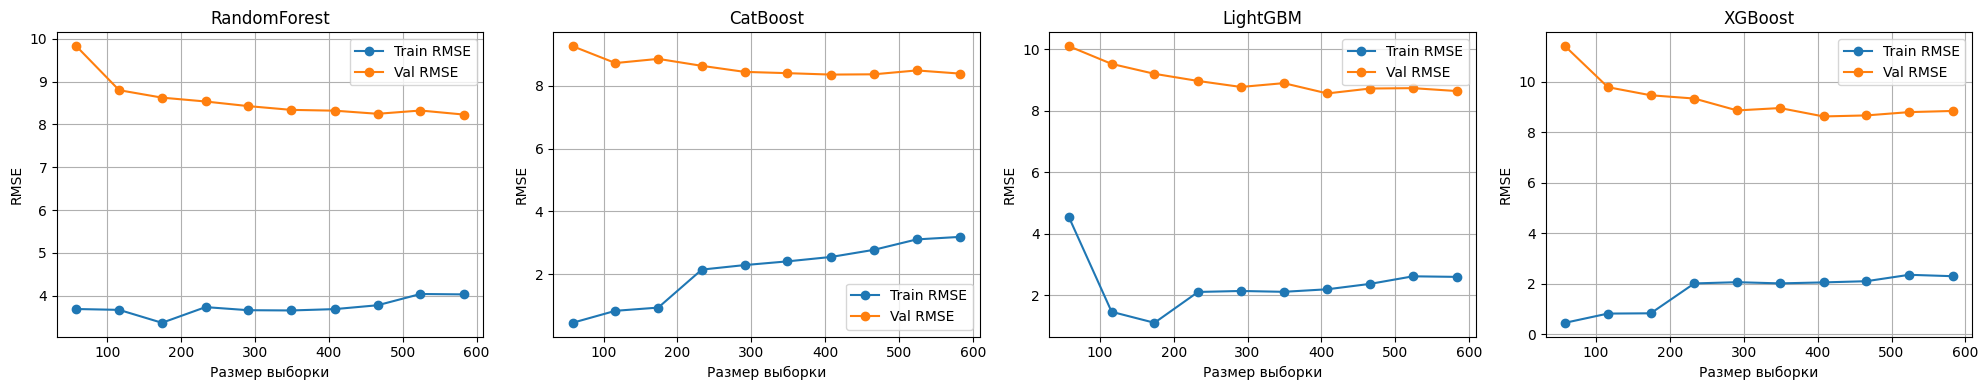

In [16]:
fig, axes = plt.subplots(1, len(models_config), figsize=(5 * len(models_config), 4))

for idx, (name, (model_class, params)) in enumerate(models_config.items()):
    train_sizes, train_scores, val_scores = learning_curve(
        model_class(**params, random_state=SEED),
        X, y[:, 0],
        cv=5,
        scoring='neg_root_mean_squared_error',
        train_sizes=np.linspace(0.1, 1.0, 10),
        n_jobs=-1
    )
    ax = axes[idx] if len(models_config) > 1 else axes
    ax.plot(train_sizes, -train_scores.mean(axis=1), 'o-', label='Train RMSE')
    ax.plot(train_sizes, -val_scores.mean(axis=1), 'o-', label='Val RMSE')
    ax.set_xlabel('Размер выборки')
    ax.set_ylabel('RMSE')
    ax.set_title(f'{name}')
    ax.legend()
    ax.grid(True)

plt.tight_layout()
plt.show()

Кривые обучения показывают, что для всех ансамблевых моделей наблюдается существенный разрыв между обучающей и валидационной ошибкой, что указывает на наличие переобучения. При этом с увеличением размера обучающей выборки значение Val RMSE постепенно снижается и стабилизируется, а Train RMSE возрастает, что свидетельствует об улучшении обобщающей способности моделей.

Наиболее стабильное поведение демонстрирует CatBoost: валидационная ошибка плавно уменьшается и достигает минимальных значений среди всех моделей, при относительно умеренном росте ошибки на обучении. Это подтверждает лучшую способность CatBoost работать с небольшими и неоднородными химическими датасетами.

## SHAP для всех boosts

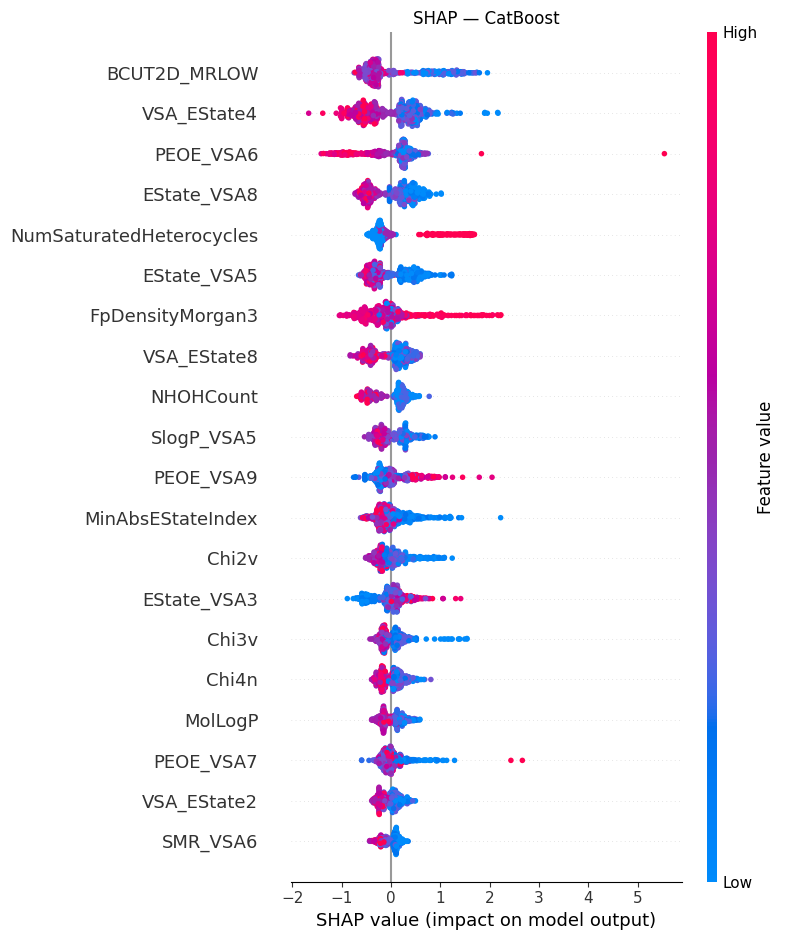

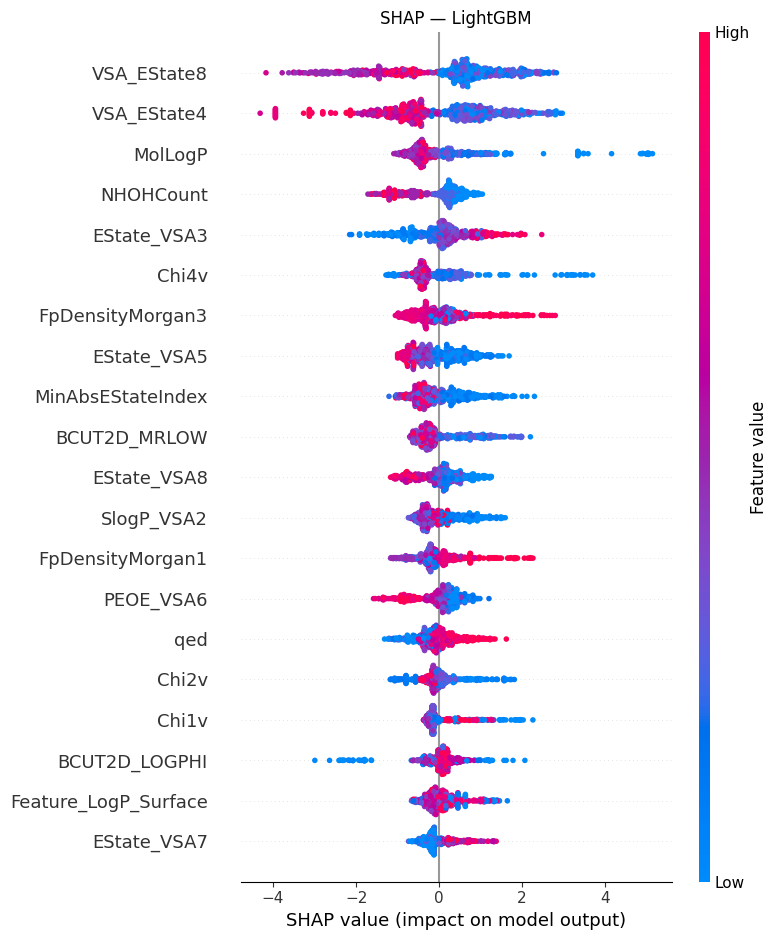

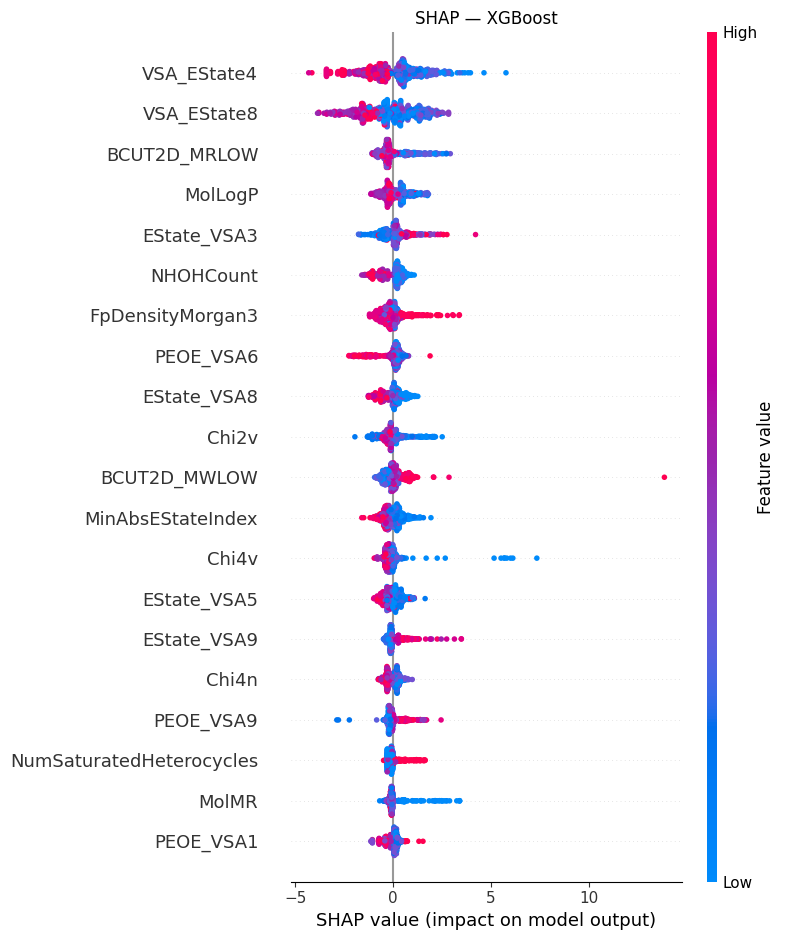

In [17]:
for name in ['CatBoost', 'LightGBM', 'XGBoost']:
    model_class, params = models_config[name]
    model_shap = model_class(**params, random_state=SEED)
    model_shap.fit(X, y[:, 0])

    explainer = shap.TreeExplainer(model_shap)
    shap_values = explainer.shap_values(X)

    shap.summary_plot(shap_values, X, feature_names=feature_cols, show=False)
    plt.title(f'SHAP — {name}')
    plt.tight_layout()
    plt.show()

SHAP-анализ подтвердил, что модели опираются преимущественно на сложные физико-химические и поверхностные дескрипторы, а не на отдельные простые линейные признаки. Наблюдается высокая согласованность между CatBoost, LightGBM и XGBoost: ключевые признаки повторяются во всех моделях, что подтверждает устойчивость найденных закономерностей.

SHAP также показал выраженные нелинейные эффекты:

- для многих признаков влияние зависит от диапазона значений;
- один и тот же дескриптор может как повышать, так и понижать прогноз;
- распределения SHAP-значений асимметричны и не соответствуют линейной зависимости.

Это дополнительно подтверждает, что задача имеет нелинейный характер, а использование ансамблевых бустинговых моделей является обоснованным.

## Submissions для всех моделей

In [18]:
'''
for name, res in results.items():
    preds_test_sqrt = res['preds_test']

    preds_test_orig = preds_test_sqrt ** 2

    submission = pd.DataFrame({
        'index': np.arange(len(preds_test_orig)),
        'IC50': preds_test_orig[:, 0],
        'CC50': preds_test_orig[:, 1],
        'SI': preds_test_orig[:, 2]
    })
    filename = f'submission_{name.lower()}_dataEF_2targ.csv'
    submission.to_csv(filename, index=False)
    print(f"Сохранён: {filename}")
'''

'\nfor name, res in results.items():\n    preds_test_sqrt = res[\'preds_test\']\n\n    preds_test_orig = preds_test_sqrt ** 2\n\n    submission = pd.DataFrame({\n        \'index\': np.arange(len(preds_test_orig)),\n        \'IC50\': preds_test_orig[:, 0],\n        \'CC50\': preds_test_orig[:, 1],\n        \'SI\': preds_test_orig[:, 2]\n    })\n    filename = f\'submission_{name.lower()}_dataEF_2targ.csv\'\n    submission.to_csv(filename, index=False)\n    print(f"Сохранён: {filename}")\n'

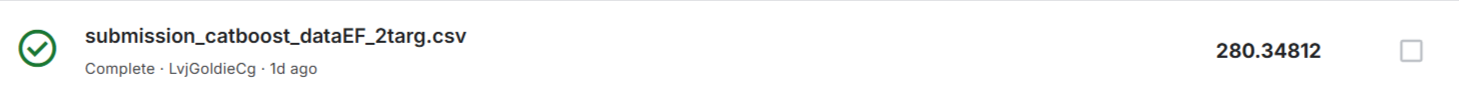

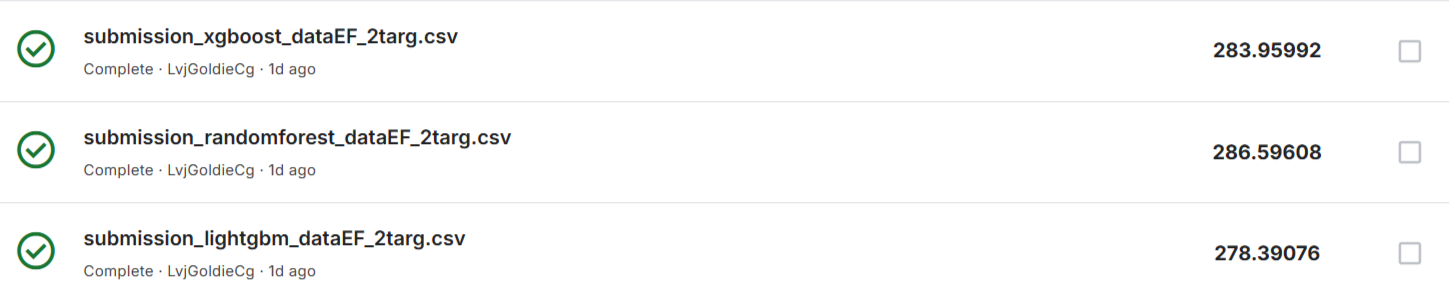